In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score, brier_score_loss
from feature_generators.temporal_features import TemporalFeatures
from feature_generators.behavioral_features import BehavioralFeatures
from feature_generators.gps_features import GPSFeatures
import shap

c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
outcomes = pd.read_csv('dataset/loan_outcomes_train.csv')
features = pd.read_csv('dataset/features.csv')
events = pd.read_csv('dataset/events.csv')
gps = pd.read_csv('dataset/gps.csv')

In [3]:
# 1. temporal featrues
temporal_builder = TemporalFeatures(outcomes_df=outcomes)
features_merged = temporal_builder.add_temporal_features()

# 2. GPS features
gps_builder = GPSFeatures(gps_df=gps, outcomes_df=features_merged)
features_merged = gps_builder.add_gps_features()

# 3. behavior features
behavioral_builder = BehavioralFeatures(
    events_df=events, 
    outcomes_df=features_merged,
    window_days=14
)
features_merged = behavioral_builder.add_behavioral_features(
    include_bigrams=True,
    include_ranks=True,
    include_diligence_stability=True,
    drop_raw=True
)

# merge with the given masked features
features_merged = features_merged.merge(
    features,
    on='user_id',
    how='inner'
)

# apparently missingness from 3 is a valualble feature so adding that, refer feature_importance notebook
features_merged['feature_3_is_missing'] = features_merged['feature_3'].isna().astype(int)

print(f"Final shape: {features_merged.shape}")
print(f"Columns: {list(features_merged.columns)}")

c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\feature_generators\gps_features.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[['lat_round', 'lon_round']].drop_duplicates().shape[0])
c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\feature_generators\gps_features.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rog)
c:\Users\soham\OneDrive\Desktop\main\loa

Final shape: (8089, 44)
Columns: ['user_id', 'application_at', 'is_repaid', 'app_hour', 'app_day_of_week', 'app_day_of_month', 'app_year', 'is_weekend', 'is_late_night', 'max_land_speed', 'gps_points_pre_app', 'unique_locations', 'dominant_location_ratio', 'location_entropy', 'radius_of_gyration', 'gps_points_pre_app_log', 'radius_of_gyration_log', 'num_events_14d', 'count_ph_inst', 'num_sessions_rank', 'active_days_rank', 'avg_session_duration', 'pct_single_event_sessions', 'events_last_24h', 'time_from_last_event_to_application', 'num_unique_screens', 'events_last_24h_ratio', 'has_events_14d', 'session_duration_rank', 'recency_rank', 'diligence_stability', 'mean_bigram_default_rate', 'max_bigram_default_rate', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_3_is_missing']


In [4]:
# chronological sorting to prevent data leakage
features_merged = features_merged.sort_values('application_at').reset_index(drop=True)

# split 90/10
split_idx = int(len(features_merged) * 0.9)
train_df = features_merged.iloc[:split_idx]
val_df = features_merged.iloc[split_idx:]

In [5]:
X_cols = [
    # Masked user features (Features)
    'feature_1', 
    'feature_2',
    'feature_4', 
    'feature_8', 
    'feature_9',
    'feature_10',
    
    # Missingness as a feature (Features)
    'feature_3_is_missing',
    
    # GPS & Location features (GPS)
    'count_ph_inst',
    'gps_points_pre_app',
    'unique_locations',
    'dominant_location_ratio',
    'location_entropy',
    'max_land_speed',
    'radius_of_gyration_log',
    'gps_points_pre_app_log',

    # Temporal features (Temporal)
    'app_hour',
    'app_day_of_week',
    'app_day_of_month',
    'app_year',
    'is_weekend',
    'is_late_night',

    # Behavioral ranks & interactions (Events)
    'num_sessions_rank',
    'active_days_rank',
    'session_duration_rank',
    'recency_rank',
    'diligence_stability',
    # if i remove these 2 features, all metrics get better for all models except xgb
    'mean_bigram_default_rate',
    'max_bigram_default_rate',
]


X_train = train_df[X_cols]
y_train = train_df['is_repaid']

X_val = val_df[X_cols]
y_val = val_df['is_repaid']

print(X_train.shape, y_train.shape)

(7280, 28) (7280,)


### Tree-based Models

In [6]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train[X_cols], y_train)
dt_probs = dt_model.predict_proba(X_val[X_cols])[:, 1]

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train[X_cols], y_train)
rf_probs = rf_model.predict_proba(X_val[X_cols])[:, 1]

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    min_child_weight=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    missing=np.nan,
    eval_metric=['logloss', 'aucpr'],
    random_state=42
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

In [9]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=10,
    learning_rate=0.003,
    auto_class_weights='Balanced',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train[X_cols], y_train, eval_set=(X_val[X_cols], y_val))

cat_probs = cat_model.predict_proba(X_val[X_cols])[:, 1]

In [10]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    is_unbalance=True, 
    importance_type='gain',
    random_state=120
)

lgb_model.fit(X_train[X_cols], y_train, eval_set=[(X_val[X_cols], y_val)], callbacks=[lgb.log_evaluation(period=0)])

lgb_probs = lgb_model.predict_proba(X_val[X_cols])[:, 1]

[LightGBM] [Info] Number of positive: 2467, number of negative: 4813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3385
[LightGBM] [Info] Number of data points in the train set: 7280, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.338874 -> initscore=-0.668318
[LightGBM] [Info] Start training from score -0.668318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [11]:
def print_metrics(y_true, y_probs, model_name):
    auc_score = roc_auc_score(y_true, y_probs)
    logloss = log_loss(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    brier = brier_score_loss(y_true, y_probs)
    
    print(f"\n{model_name} Performance Metrics")
    print(f"ROC-AUC:     {auc_score:.4f}")
    print(f"PR-AUC:      {pr_auc:.4f}")
    print(f"Log-Loss:    {logloss:.4f}")
    print(f"Brier Score: {brier:.4f}")

In [12]:
print_metrics(y_val, dt_probs, "Decision Tree")
print_metrics(y_val, rf_probs, "Random Forest")
print_metrics(y_val, xgb_probs, "XGBoost")
print_metrics(y_val, cat_probs, "CatBoost")
print_metrics(y_val, lgb_probs, "LightGBM")


Decision Tree Performance Metrics
ROC-AUC:     0.5296
PR-AUC:      0.3555
Log-Loss:    0.6705
Brier Score: 0.2389

Random Forest Performance Metrics
ROC-AUC:     0.5668
PR-AUC:      0.3940
Log-Loss:    0.6177
Brier Score: 0.2127

XGBoost Performance Metrics
ROC-AUC:     0.6008
PR-AUC:      0.4231
Log-Loss:    0.6065
Brier Score: 0.2083

CatBoost Performance Metrics
ROC-AUC:     0.5999
PR-AUC:      0.4361
Log-Loss:    0.6456
Brier Score: 0.2265

LightGBM Performance Metrics
ROC-AUC:     0.5829
PR-AUC:      0.4283
Log-Loss:    0.6407
Brier Score: 0.2248


In [13]:
models ={
    'XGBoost': xgb_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'CatBoost': cat_model,
    'LightGBM': lgb_model
}

### Model Explanability and Feature Importance in Model 

c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,XGBoost,Decision Tree,Random Forest,CatBoost,LightGBM,mean_importance,std_importance
feature_1,0.132310,0.059150,0.038868,0.112476,0.216971,0.111955,0.062567
feature_2,0.141296,0.016323,0.032404,0.102280,0.174221,0.093305,0.060936
session_duration_rank,0.062087,0.029141,0.021839,0.037604,0.096778,0.049490,0.027257
feature_4,0.024959,0.004361,0.012903,0.029518,0.103811,0.035110,0.035476
num_sessions_rank,0.048219,0.003643,0.014447,0.045579,0.058890,0.034156,0.021258
mean_bigram_default_rate,0.030771,0.012163,0.012516,0.019300,0.070708,0.029092,0.021872
feature_9,0.045668,0.005030,0.009045,0.023047,0.060623,0.028683,0.021380
app_year,0.013563,0.019518,0.006837,0.032723,0.050192,0.024567,0.015389
feature_10,0.037759,0.014178,0.008637,0.021432,0.035841,0.023569,0.011556
gps_points_pre_app,0.025570,0.000000,0.005552,0.006059,0.075672,0.022571,0.027930


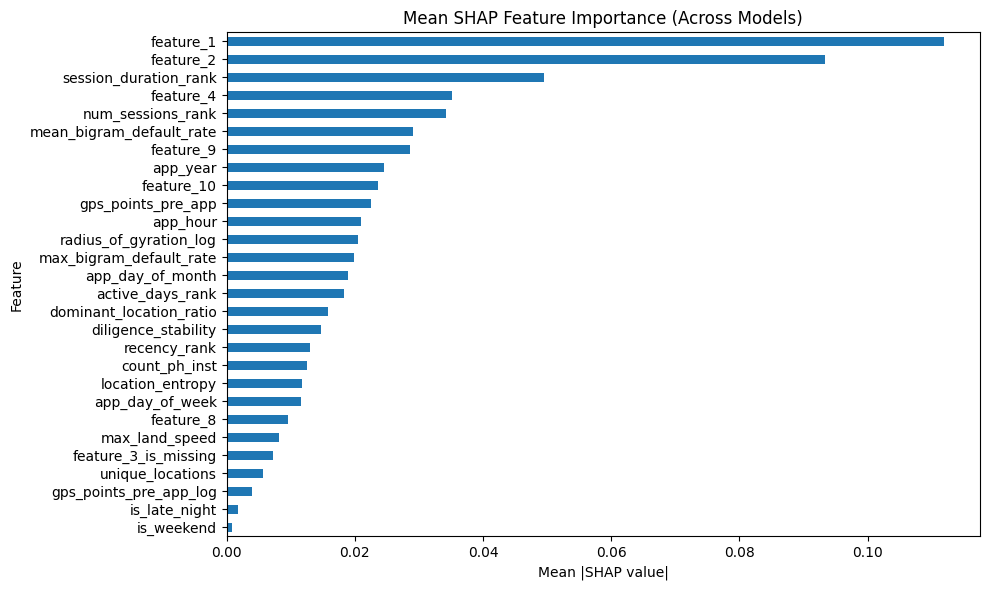

In [14]:
shap.initjs()

MAX_SAMPLES = 5000
SHAP_CORR_THRESHOLD = 0.85
FEATURE_CORR_THRESHOLD = 0.85
TOP_N = 20
all_importances = []
all_shap_values = {}
X_sample = None

for model_name, model in models.items():

    if len(X_val) > MAX_SAMPLES:
        X_s = X_val.sample(MAX_SAMPLES, random_state=42)
    else:
        X_s = X_val.copy()

    if X_sample is None:
        X_sample = X_s.copy()

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_s)

    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]

    all_shap_values[model_name] = shap_vals

    # feature importance
    importance = np.abs(shap_vals).mean(axis=0)
    all_importances.append(
        pd.Series(importance, index=X_s.columns, name=model_name)
    )

importance_df = pd.concat(all_importances, axis=1)
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df["std_importance"] = importance_df.std(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

display(importance_df.head(100))

plt.figure(figsize=(10, 6))
importance_df["mean_importance"] \
    .head(100) \
    .sort_values() \
    .plot(kind="barh")

plt.title("Mean SHAP Feature Importance (Across Models)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Redundant Features to drop


SHAP Summary Plot — XGBoost


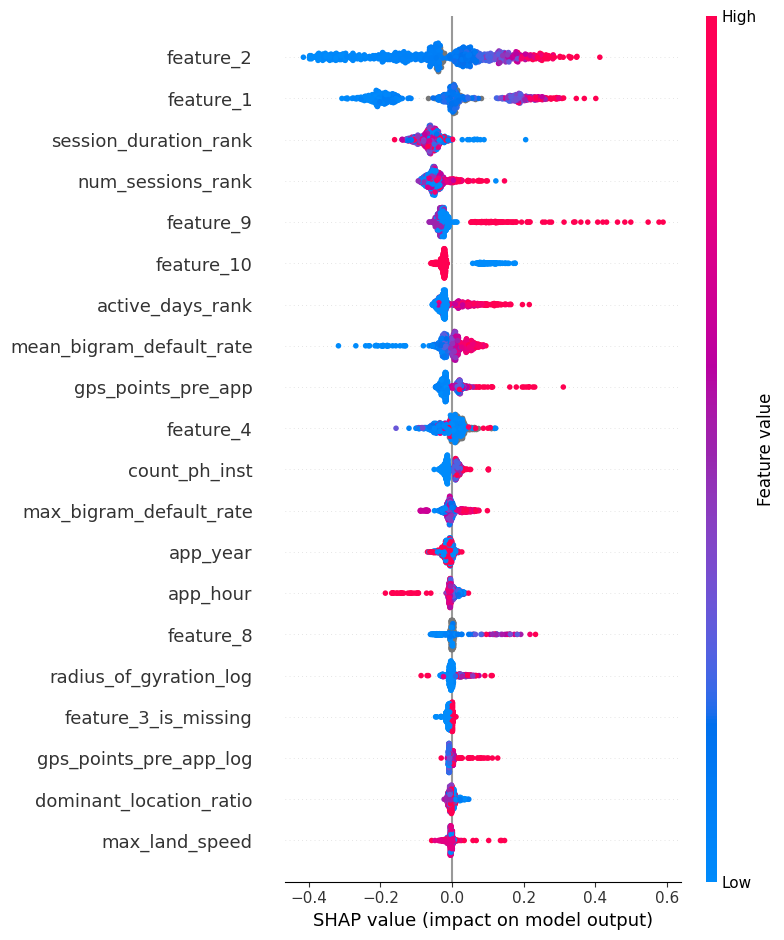

c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\soham\OneDrive\Desktop\main\loan_outcome_prediction\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


""


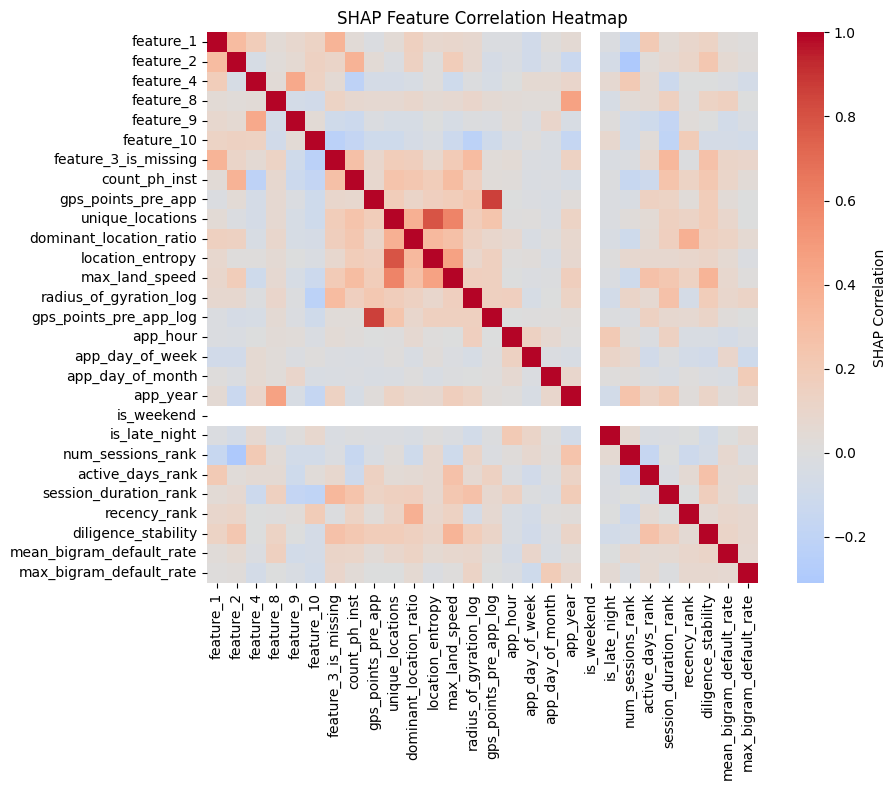

In [15]:
ref_model = list(all_shap_values.keys())[0]
print(f"\nSHAP Summary Plot — {ref_model}")

shap.summary_plot(
    all_shap_values[ref_model],
    X_sample,
    max_display=TOP_N,
    show=True
)

shap_vals_ref = np.abs(all_shap_values[ref_model])

shap_corr = np.corrcoef(shap_vals_ref.T)
shap_corr_df = pd.DataFrame(
    shap_corr,
    index=X_sample.columns,
    columns=X_sample.columns
)

feature_corr = X_sample.corr().abs()

redundant_pairs = []
features = X_sample.columns.tolist()

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        f1, f2 = features[i], features[j]

        if (
            shap_corr_df.loc[f1, f2] > SHAP_CORR_THRESHOLD and
            feature_corr.loc[f1, f2] > FEATURE_CORR_THRESHOLD
        ):
            imp1 = importance_df.loc[f1, "mean_importance"]
            imp2 = importance_df.loc[f2, "mean_importance"]
            drop = f1 if imp1 < imp2 else f2

            redundant_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "shap_corr": shap_corr_df.loc[f1, f2],
                "feature_corr": feature_corr.loc[f1, f2],
                "drop_candidate": drop
            })

redundant_df = pd.DataFrame(redundant_pairs)

if not redundant_df.empty:
    redundant_df = redundant_df.sort_values(
        ["shap_corr", "feature_corr"],
        ascending=False
    )

display(redundant_df.head(15))

plt.figure(figsize=(10, 8))
sns.heatmap(
    shap_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "SHAP Correlation"}
)

plt.title("SHAP Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [18]:
low_importance_cutoff = importance_df["mean_importance"].quantile(0.25)

low_importance_features = importance_df[
    importance_df["mean_importance"] < low_importance_cutoff
].index.tolist()

if not redundant_df.empty and "drop_candidate" in redundant_df.columns:
    redundant_features = redundant_df["drop_candidate"].unique().tolist()
else:
    redundant_features = []

features_to_drop = sorted(set(low_importance_features + redundant_features))

print("Droppable Features")
print(features_to_drop)

Droppable Features
['feature_3_is_missing', 'feature_8', 'gps_points_pre_app_log', 'is_late_night', 'is_weekend', 'max_land_speed', 'unique_locations']
